## Imports

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import pylab as pl
import numpy as np
import scipy as sp
from scipy import stats
import yaml

In [5]:
from caa_model.config import *
from caa_model.models import base_model, disp_classic, sisp_classic, sisp_var_rbound, sisp_z0_var_rbound, disp_staggered
from caa_model.models.results import *
from caa_model.models.disp_classic import DISPClassicDDM
from caa_model.models.sisp_classic import SISPClassicDDM
from caa_model.models.sisp_var_rbound import SISPVarRBoundDDM
from caa_model.models.sisp_z0_var_rbound import SISPZ0VarRBoundDDM
from caa_model.models.disp_staggered import DISPStaggeredDDM

## Setup

Notes:
- Use qmpe
- 5 quantiles
- Asymmetric quantiles
- Probability normalization: final probability of predicted proprotiosn should add to 1

TODO:
- Asymptotic decrease in recollection
- Initial time variance
- Lapse rate parameter for qmpe and qmle

In [6]:
data = base_model.DATA

caa_cfg = CAAConfig(
    delta_t=0.025,
    nr_ssteps=8192,
    nr_samples=10000,
    max_t=8.0,
)

In [7]:
def display_comparison(evals: list[ModelEvaluation]):
    """Renders a side-by-side comparison Markdown table for multiple ModelEvaluations."""
    methods = " | ".join([f"`{e.method.upper()}`" for e in evals])
    align = " | ".join(["---:"] * len(evals))
    
    trials = " | ".join([f"{e.n_trials:,}" for e in evals])
    params = " | ".join([f"{e.n_params}" for e in evals])
    nll    = " | ".join([f"{e.nll:.2f}" for e in evals])
    aic    = " | ".join([f"**{e.aic:.2f}**" for e in evals])
    bic    = " | ".join([f"**{e.bic:.2f}**" for e in evals])

    md_table = f"""
### Model Evaluation Comparison

| Metric | {methods} |
| :--- | {align} |
| **Trials ($N$)** | {trials} |
| **Parameters ($k$)** | {params} |
| **Negative Log-Likelihood** | {nll} |
| **AIC** | {aic} |
| **BIC** | {bic} |
"""
    display(Markdown(md_table))

In [8]:
def fit_methods(model, methods, **kwargs):
    return {m: model.fit(method=m, **kwargs) for m in methods}

methods = ["qmle", "qmpe"]

## RT Data

In [9]:
# Assuming 3 confidence levels (0, 1, 2)
conf_levels = [0, 1, 2]

print("=== TARGETS (Old Words) ===")
for conf in conf_levels:
    rem_count = len(data.rem_hit.rt[data.rem_hit.conf == conf])
    know_count = len(data.know_hit.rt[data.know_hit.conf == conf])
    print(f"Conf {conf} | Remember: {rem_count:<4} | Know: {know_count:<4}")

print(f"Misses: {len(data.miss.rt)}")


print("\n=== LURES (New Words) ===")
for conf in conf_levels:
    rem_fa_count = len(data.rem_fa.rt[data.rem_fa.conf == conf])
    know_fa_count = len(data.know_fa.rt[data.know_fa.conf == conf])
    print(f"Conf {conf} | Rem FA:   {rem_fa_count:<4} | Know FA: {know_fa_count:<4}")

print(f"Correct Rejections: {len(data.CR.rt)}")

=== TARGETS (Old Words) ===
Conf 0 | Remember: 23   | Know: 47  
Conf 1 | Remember: 362  | Know: 431 
Conf 2 | Remember: 917  | Know: 526 
Misses: 1543

=== LURES (New Words) ===
Conf 0 | Rem FA:   28   | Know FA: 59  
Conf 1 | Rem FA:   228  | Know FA: 356 
Conf 2 | Rem FA:   195  | Know FA: 164 
Correct Rejections: 2856


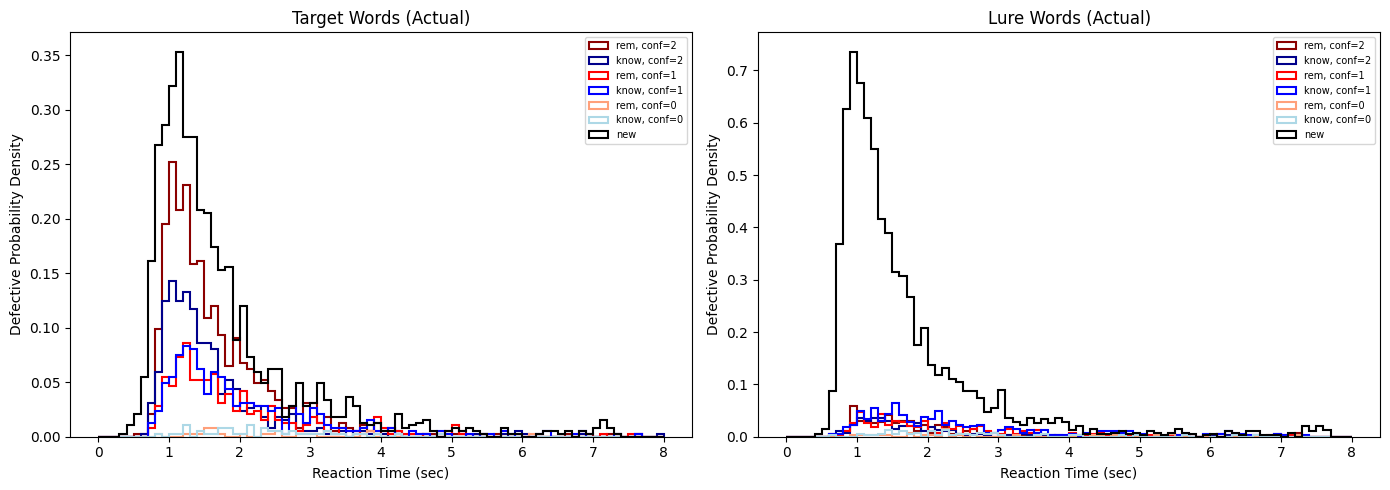

In [10]:
# Calculate total N for Targets and Lures
N_target = len(data.rem_hit.rt) + len(data.know_hit.rt) + len(data.miss.rt)
N_lure = len(data.rem_fa.rt) + len(data.know_fa.rt) + len(data.CR.rt)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
confidence_labels = ["conf=2", "conf=1", "conf=0"]
conf_vals = [2, 1, 0]

colors_rem = ["darkred", "red", "lightsalmon"]
colors_know = ["darkblue", "blue", "lightblue"]

# Define fixed bins (e.g., 50ms intervals) up to your model's max_t
bin_width = 0.1
bins = np.arange(0, caa_cfg.max_t + bin_width, bin_width)


def plot_empirical_hist(ax, rt_data, total_N, color, label):
    """Plots true data frequencies as step histograms without Gaussian smoothing artifacts."""
    if len(rt_data) > 0:
        # Weight each trial so the area under all curves combined equals 1.0
        weights = np.ones_like(rt_data) / (total_N * bin_width)

        # histtype='step' draws just the outline, preventing visual clutter
        ax.hist(rt_data, bins=bins, weights=weights, color=color, label=label, histtype="step", linewidth=1.5)


# --- Target Words (Empirical) ---
for i, conf_val in enumerate(conf_vals):
    rt_subset_rem = data.rem_hit.rt[data.rem_hit.conf == conf_val]
    plot_empirical_hist(axes[0], rt_subset_rem, N_target, colors_rem[i], f"rem, {confidence_labels[i]}")

    rt_subset_know = data.know_hit.rt[data.know_hit.conf == conf_val]
    plot_empirical_hist(axes[0], rt_subset_know, N_target, colors_know[i], f"know, {confidence_labels[i]}")

plot_empirical_hist(axes[0], data.miss.rt, N_target, "black", "new")

axes[0].set_title("Target Words (Actual)")
axes[0].set_xlabel("Reaction Time (sec)")
axes[0].set_ylabel("Defective Probability Density")
axes[0].legend(fontsize=7)

# --- Lure Words (Empirical) ---
for i, conf_val in enumerate(conf_vals):
    rt_subset_rem = data.rem_fa.rt[data.rem_fa.conf == conf_val]
    plot_empirical_hist(axes[1], rt_subset_rem, N_lure, colors_rem[i], f"rem, {confidence_labels[i]}")

    rt_subset_know = data.know_fa.rt[data.know_fa.conf == conf_val]
    plot_empirical_hist(axes[1], rt_subset_know, N_lure, colors_know[i], f"know, {confidence_labels[i]}")

plot_empirical_hist(axes[1], data.CR.rt, N_lure, "black", "new")

axes[1].set_title("Lure Words (Actual)")
axes[1].set_xlabel("Reaction Time (sec)")
axes[1].set_ylabel("Defective Probability Density")
axes[1].legend(fontsize=7)

plt.tight_layout()
plt.show()

## DISP Classic

In [11]:
disp_model = DISPClassicDDM(
    config=caa_cfg,
    nr_threads=1,
)

param_bounds = disp_classic.param_bounds

# Optimize over entire data
# qmle_opt = disp_model.fit(param_bounds=param_bounds, method="qmle", nr_workers=7)
# disp_opt = fit_methods(disp_model, methods, param_bounds=param_bounds, nr_workers=7)

disp_opt = {
    'qmle': DISPClassicDDM.Params(c=np.float64(1.0083030600944243), mu_r=np.float64(0.13850193211276146), mu_f=np.float64(0.19232073223889184), d_r=np.float64(0.1121328895294123), d_f=np.float64(0.31441939625800186), tc_bound=np.float64(0.055720568817881136), r_bound=np.float64(0.35495727933436094), z0=np.float64(-0.17282762910507243), mu_r_new=np.float64(-0.0925421271654471), mu_f_new=np.float64(-0.21786294626190794), t_post=np.float64(0.4137882945349166), t0=np.float64(0.6093673522988403)),
    'qmpe': DISPClassicDDM.Params(c=np.float64(1.0092385822936774), mu_r=np.float64(0.11325731922334464), mu_f=np.float64(0.21779977200843353), d_r=np.float64(0.10521435455150056), d_f=np.float64(0.3470664982867556), tc_bound=np.float64(0.042970639278343395), r_bound=np.float64(0.28951152923167545), z0=np.float64(-0.1539694818643085), mu_r_new=np.float64(-0.1032426034612505), mu_f_new=np.float64(-0.24436157427112998), t_post=np.float64(0.39828581007998054), t0=np.float64(0.6374615695757432)),
    'cml': DISPClassicDDM.Params(c=np.float64(1.0234544749163188), mu_r=np.float64(0.21543561031285494), mu_f=np.float64(0.12355048027370419), d_r=np.float64(0.10465469488119335), d_f=np.float64(0.3233760326114212), tc_bound=np.float64(0.0414895299022639), r_bound=np.float64(0.4603667517386504), z0=np.float64(-0.15759756113224072), mu_r_new=np.float64(0.049414229010858235), mu_f_new=np.float64(-0.358823277402136), t_post=np.float64(0.4524589235103297), t0=np.float64(0.5748741743961203))
}

method = "qmpe"
params_est = disp_opt[method]


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 7,735 | 7,735 | 7,735 |
| **Parameters ($k$)** | 12 | 12 | 12 |
| **Negative Log-Likelihood** | 418.76 | 440.73 | 18369.35 |
| **AIC** | **861.51** | **905.46** | **36762.70** |
| **BIC** | **944.95** | **988.90** | **36846.14** |


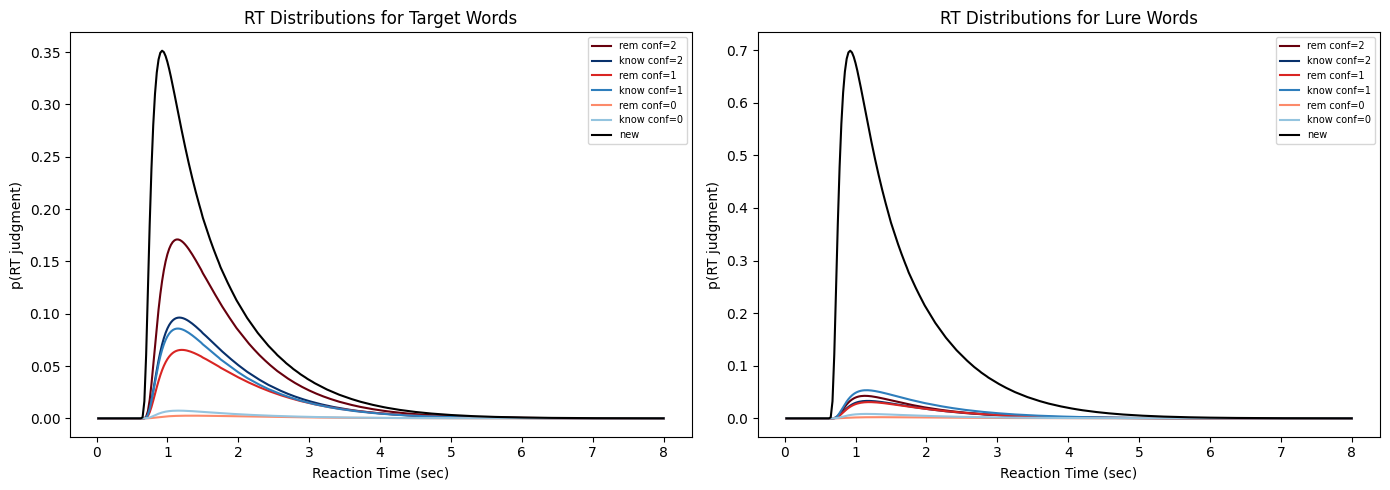

In [12]:
results = [
    disp_model.evaluate(params_est, method="qmpe"),
    disp_model.evaluate(params_est, method="qmle"),
    disp_model.evaluate(params_est, method="cml"),
]

display_comparison(results)

disp_model.plot_rt_distributions(params_est);

## SISP Z0 Var R Bound

In [13]:
sisp_z0_var_rbound_model = SISPZ0VarRBoundDDM(
    config=caa_cfg,
    nr_threads=1,
)

param_bounds = sisp_z0_var_rbound.param_bounds

# Optimize over entire data
# sisp_z0_var_rbound_opt = fit_methods(sisp_z0_var_rbound_model, methods, param_bounds=param_bounds, nr_workers=7)

sisp_z0_var_rbound_opt = {'qmle': SISPZ0VarRBoundDDM.Params(c=np.float64(1.0025302418725117), mu_t=np.float64(0.31361258851163604), mu_l=np.float64(-0.3391203875788821), d=np.float64(0.42153990547160725), tc_bound=np.float64(0.05051294798530494), r_bound_offset=np.float64(1.115119825072135), sigma_r_bound=np.float64(1.8137046364645135), z0=np.float64(-0.14959837834298156), t_post=np.float64(0.4141001380984841), t0=np.float64(0.5953304993380385)),
 'qmpe': SISPZ0VarRBoundDDM.Params(c=np.float64(1.004269834116802), mu_t=np.float64(0.3261960003263855), mu_l=np.float64(-0.35129030228568925), d=np.float64(0.45154471964165344), tc_bound=np.float64(0.043736693393246096), r_bound_offset=np.float64(1.0945655352001413), sigma_r_bound=np.float64(1.8471827989468068), z0=np.float64(-0.15100990820384186), t_post=np.float64(0.3901680374401064), t0=np.float64(0.6298431418134491))}

method = "qmpe"
params_est = sisp_z0_var_rbound_opt[method]


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 7,735 | 7,735 | 7,735 |
| **Parameters ($k$)** | 10 | 10 | 10 |
| **Negative Log-Likelihood** | 414.47 | 434.41 | 18367.17 |
| **AIC** | **848.94** | **888.82** | **36754.34** |
| **BIC** | **918.48** | **958.35** | **36823.88** |


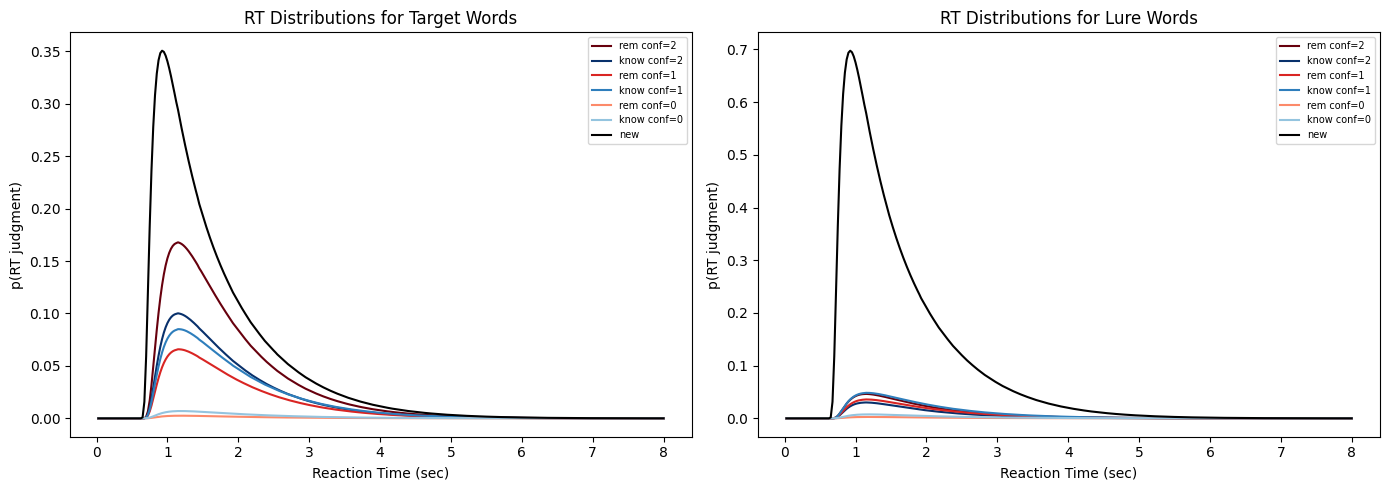

In [14]:
results = [
    sisp_z0_var_rbound_model.evaluate(params_est, method="qmpe"),
    sisp_z0_var_rbound_model.evaluate(params_est, method="qmle"),
    sisp_z0_var_rbound_model.evaluate(params_est, method="cml"),
]

display_comparison(results)

sisp_z0_var_rbound_model.plot_rt_distributions(params_est);

## SISP Var R Bound

In [ ]:
sisp_var_rbound_model = SISPVarRBoundDDM(
    config=caa_cfg,
    nr_threads=1,
)

param_bounds = sisp_var_rbound.param_bounds

# Optimize over entire data
# sisp_var_rbound_opt = fit_methods(sisp_var_rbound_model, methods, param_bounds=param_bounds, nr_workers=7)

sisp_var_rbound_opt = {'qmle': SISPVarRBoundDDM.Params(c=np.float64(0.982623859278037), mu_t=np.float64(0.2860543238730795), mu_l=np.float64(-0.3199142720220682), d=np.float64(0.4230894741538903), tc_bound=np.float64(0.05906693362719409), r_bound_offset=np.float64(1.0631157325058616), sigma_r_bound=np.float64(1.6978370542675307), z0_t=np.float64(-0.12435231482512896), z0_l=np.float64(-0.16355673279222493), t_post=np.float64(0.3806844091534196), t0=np.float64(0.5941244223068939)),
 'qmpe': SISPVarRBoundDDM.Params(c=np.float64(1.0035613933205312), mu_t=np.float64(0.30602155258999725), mu_l=np.float64(-0.3221096153869847), d=np.float64(0.44719055600405444), tc_bound=np.float64(0.04396106038014195), r_bound_offset=np.float64(1.0934638782878143), sigma_r_bound=np.float64(1.8179152723917587), z0_t=np.float64(-0.12472845214989038), z0_l=np.float64(-0.1820105918227459), t_post=np.float64(0.39589542092301294), t0=np.float64(0.6312127074596804))}

method = "qmpe"
params_est = sisp_var_rbound_opt[method]

differential_evolution step 1: f(x)= 4918.026113702099
differential_evolution step 2: f(x)= 3696.798719083021
differential_evolution step 3: f(x)= 3696.798719083021
differential_evolution step 4: f(x)= 2977.7391555542454
differential_evolution step 5: f(x)= 2919.1067906129138
differential_evolution step 6: f(x)= 1271.1427102061807
differential_evolution step 7: f(x)= 1271.1427102061807
differential_evolution step 8: f(x)= 1271.1427102061807
differential_evolution step 9: f(x)= 1271.1427102061807
differential_evolution step 10: f(x)= 1271.1427102061807
differential_evolution step 11: f(x)= 1124.6459017673387
differential_evolution step 12: f(x)= 1124.6459017673387
differential_evolution step 13: f(x)= 969.2093603029971
differential_evolution step 14: f(x)= 969.2093603029971
differential_evolution step 15: f(x)= 969.2093603029971
differential_evolution step 16: f(x)= 969.2093603029971
differential_evolution step 17: f(x)= 781.4607637029185
differential_evolution step 18: f(x)= 781.460763


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 7,735 | 7,735 | 7,735 |
| **Parameters ($k$)** | 11 | 11 | 11 |
| **Negative Log-Likelihood** | 408.71 | 419.96 | 18356.84 |
| **AIC** | **839.43** | **861.91** | **36735.69** |
| **BIC** | **915.92** | **938.40** | **36812.18** |


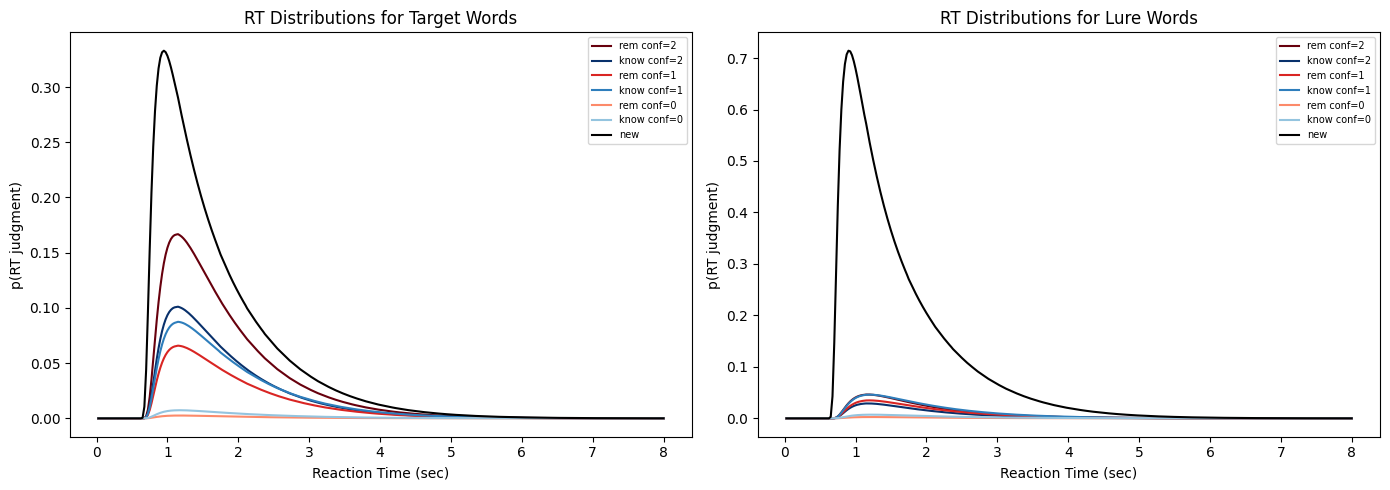

In [32]:
results = [
    sisp_var_rbound_model.evaluate(params_est, method="qmpe"),
    sisp_var_rbound_model.evaluate(params_est, method="qmle"),
    sisp_var_rbound_model.evaluate(params_est, method="cml"),
]

display_comparison(results)

sisp_var_rbound_model.plot_rt_distributions(params_est);

## DISP Staggered

In [13]:
disp_staggered_model = DISPStaggeredDDM(
    config=caa_cfg,
    nr_threads=1,
)

param_bounds = disp_staggered.param_bounds

# Optimize over entire data
# disp_staggered_opt = fit_methods(disp_staggered_model, methods, param_bounds=param_bounds, nr_workers=7)

disp_staggered_opt = {
    'qmle': DISPStaggeredDDM.Params(c=np.float64(0.9805144878333434), mu_r=np.float64(0.08122172524295136), mu_f=np.float64(0.2053987795615883), d_r=np.float64(0.08736161989864574), d_f=np.float64(0.3421813460087629), tc_bound=np.float64(0.05938006657748657), r_bound=np.float64(0.21446121096924298), z0=np.float64(-0.1106581849984806), z0_new=np.float64(-0.17371368345945398), mu_r_new=np.float64(-0.08888776239481999), mu_f_new=np.float64(-0.2277591925549105), t_post=np.float64(0.3640081938167594), t_delay_r=np.float64(0.029235146612983105), t0=np.float64(0.6024337299775664)),
    'qmpe': DISPStaggeredDDM.Params(c=np.float64(1.0155739212586883), mu_r=np.float64(0.06519506757633807), mu_f=np.float64(0.24596242143025204), d_r=np.float64(0.07941847590436699), d_f=np.float64(0.3792605196196342), tc_bound=np.float64(0.03861814069808822), r_bound=np.float64(0.15742213001591476), z0=np.float64(-0.12189062125973753), z0_new=np.float64(-0.2031045554318242), mu_r_new=np.float64(-0.11298961972338514), mu_f_new=np.float64(-0.19875241397412916), t_post=np.float64(0.39886707086830475), t_delay_r=np.float64(0.07817964539569117), t0=np.float64(0.6328353721306741)),
    'cml': DISPStaggeredDDM.Params(c=np.float64(1.048591923085804), mu_r=np.float64(-0.014183051698463987), mu_f=np.float64(0.33901612630178113), d_r=np.float64(0.1500067300372802), d_f=np.float64(0.33806506859416646), tc_bound=np.float64(0.017320013380434755), r_bound=np.float64(0.07569984717419526), z0=np.float64(-0.15555563581352938), z0_new=np.float64(-0.2685842593387985), mu_r_new=np.float64(-0.31189098793995473), mu_f_new=np.float64(0.026984928591890334), t_post=np.float64(0.407613256254892), t_delay_r=np.float64(0.3072194422976065), t0=np.float64(0.5490135703942112))
}

# disp_staggered_opt = {
#     'qmle': DISPStaggeredDDM.Params(c=np.float64(0.9696368427246786), mu_r=np.float64(0.0866133898804743), mu_f=np.float64(0.17976181729220597), d_r=np.float64(0.10547718750171013), d_f=np.float64(0.308818318605927), tc_bound=np.float64(0.065434334217461), r_bound=np.float64(0.23015250658396363), z0=np.float64(-0.10037788724237282), z0_new=np.float64(-0.1897219438618008), mu_r_new=np.float64(-0.1287378272706921), mu_f_new=np.float64(-0.15481488460513887), t_post=np.float64(0.3819305120360762), t_delay_r=np.float64(0.10154744665220895), t0=np.float64(0.545183185180014)),
#     'qmpe': DISPStaggeredDDM.Params(c=np.float64(1.00442979084296), mu_r=np.float64(0.08114409268865266), mu_f=np.float64(0.21450280661732885), d_r=np.float64(0.08711172365595438), d_f=np.float64(0.3610046026013649), tc_bound=np.float64(0.041686754792147646), r_bound=np.float64(0.2140277939367582), z0=np.float64(-0.11438462717573925), z0_new=np.float64(-0.18768718074103663), mu_r_new=np.float64(-0.10435883785583189), mu_f_new=np.float64(-0.21324228409010254), t_post=np.float64(0.3988272999159962), t_delay_r=np.float64(0.005669038457066634), t0=np.float64(0.6236675581871447))
# }

method = "qmle"
params_est = disp_staggered_opt[method]


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 7,735 | 7,735 | 7,735 |
| **Parameters ($k$)** | 14 | 14 | 14 |
| **Negative Log-Likelihood** | 418.46 | 397.53 | 18333.25 |
| **AIC** | **864.93** | **823.05** | **36694.50** |
| **BIC** | **962.28** | **920.40** | **36791.85** |


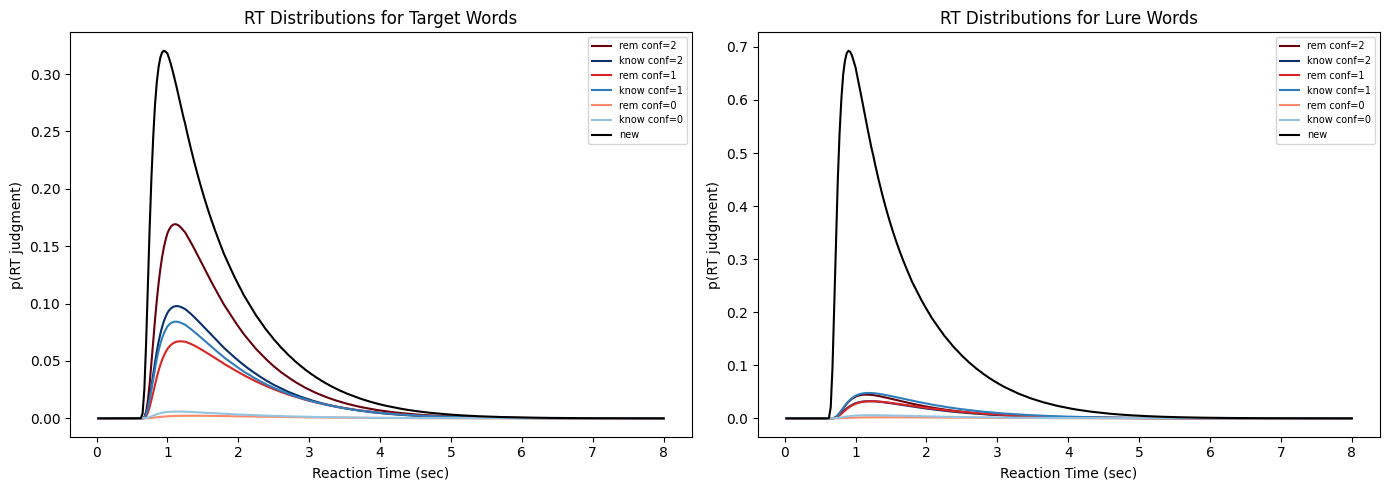

In [14]:
results = [
    disp_staggered_model.evaluate(params_est, method="qmpe"),
    disp_staggered_model.evaluate(params_est, method="qmle"),
    disp_staggered_model.evaluate(params_est, method="cml"),
]

display_comparison(results)

fig, axes = disp_staggered_model.plot_rt_distributions(params_est, show=False)

## SISP Classic

In [16]:
sisp_classic_model = SISPClassicDDM(
    config=caa_cfg,
    nr_threads=1,
)

param_bounds = sisp_classic.param_bounds

# Optimize over entire data
# sisp_classic_opt = fit_methods(sisp_classic_model, methods, param_bounds=param_bounds, nr_workers=7)

# sisp_classic_opt = {
#     'qmle': SISPClassicDDM.Params(c=np.float64(0.7521561080117527), mu_t=np.float64(0.14258827059234508), mu_l=np.float64(0.009860089096247561), d=np.float64(0.23952800791261064), tc_bound=np.float64(0.2534096231421228), r_bound_offset=np.float64(0.9942445202501391), z0_t=np.float64(-0.02085198044897245), z0_l=np.float64(-0.3767479176730697), t_post=np.float64(0.3447404579180302), t0=np.float64(0.49558338865624396)),
#     'qmpe': SISPClassicDDM.Params(c=np.float64(0.8861619380311199), mu_t=np.float64(0.09411561089979442), mu_l=np.float64(0.001749896702882732), d=np.float64(0.42933715506015346), tc_bound=np.float64(0.07094165943753428), r_bound_offset=np.float64(1.124236615017316), z0_t=np.float64(-0.0023294571604742693), z0_l=np.float64(-0.38420647233690464), t_post=np.float64(0.26903351319498225), t0=np.float64(0.6431898734600363))
# }

sisp_classic_opt = {
    'qmle': SISPClassicDDM.Params(c=np.float64(0.8622378462435147), mu_t=np.float64(0.11673556020269979), mu_l=np.float64(0.000609615289424843), d=np.float64(0.4060554362361406), tc_bound=np.float64(0.11285291395316274), r_bound_offset=np.float64(1.0853853933193625), z0_t=np.float64(-0.0020610735283302893), z0_l=np.float64(-0.3658205646552306), t_post=np.float64(0.2450837974968667), t0=np.float64(0.6175398615829195)),
    'qmpe': SISPClassicDDM.Params(c=np.float64(0.8751397562944294), mu_t=np.float64(0.32351866429167564), mu_l=np.float64(0.003927778787796292), d=np.float64(0.49793896963687), tc_bound=np.float64(0.015939363742185582), r_bound_offset=np.float64(1.5481584839157323), z0_t=np.float64(-0.17356105029700652), z0_l=np.float64(-0.3377470518687792), t_post=np.float64(0.4709534329517068), t0=np.float64(0.6874999946188178))
}

method = "qmpe"
params_est = sisp_classic_opt[method]


### Model Evaluation Comparison

| Metric | `QMPE` | `QMLE` | `CML` |
| :--- | ---: | ---: | ---: |
| **Trials ($N$)** | 7,735 | 7,735 | 7,735 |
| **Parameters ($k$)** | 10 | 10 | 10 |
| **Negative Log-Likelihood** | 2480.85 | 3146.49 | 20661.09 |
| **AIC** | **4981.70** | **6312.99** | **41342.19** |
| **BIC** | **5051.24** | **6382.52** | **41411.72** |


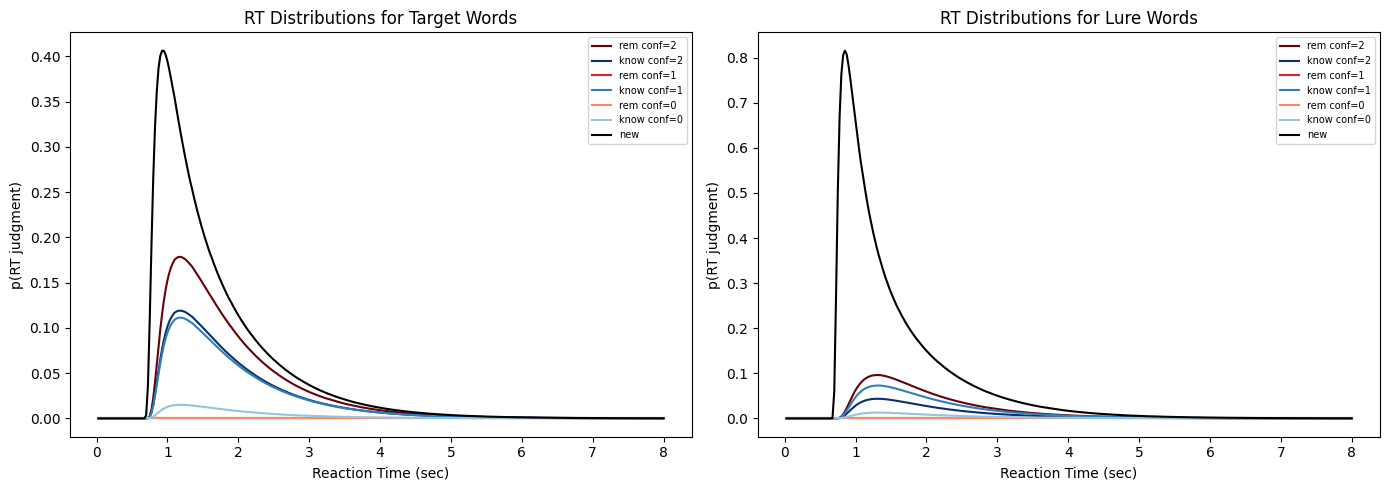

In [18]:
results = [
    sisp_classic_model.evaluate(params_est, method="qmpe"),
    sisp_classic_model.evaluate(params_est, method="qmle"),
    sisp_classic_model.evaluate(params_est, method="cml"),
]

display_comparison(results)

fig, axes = sisp_classic_model.plot_rt_distributions(params_est, show=False)

## Optimizing

In [27]:
# m = ["qmle", "qmpe"]
# # disp_opt = fit_methods(disp_model, m, param_bounds=disp_classic.param_bounds, nr_workers=7)
# disp_staggered_opt = fit_methods(disp_staggered_model, m, param_bounds=disp_staggered.param_bounds, nr_workers=7)

In [ ]:
# param_bounds = sisp_classic.param_bounds
# sisp_classic_opt = fit_methods(sisp_classic_model, methods, param_bounds=param_bounds, nr_workers=7)
# sisp_onstrained_lure_opt = fit_methods(sisp_classic_lure_model, methods, param_bounds=param_bounds, nr_workers=7)
# sisp_classic_target_opt = fit_methods(sisp_classic_target_model, methods, param_bounds=param_bounds, nr_workers=7)